In [40]:
import sys, os 
import geopandas as gpd 
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats_na_dropped.geojson')
gdf = gpd.read_file(data_path)

In [47]:
from sklearn.model_selection import train_test_split

features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std',  'eccentricity', 'solidity',
            'mean_intensity', 'perimeter', 'compactness', 'shape_index','area', 'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity']

def load_train_test_data(raw_target):
    if raw_target == 'CODIGO_GROUP_2':
        label_map = {
            '0' : 'Building',
            '11' : 'Urban',
            '12' : 'Highway',
            '21' : 'Seasonal crops',
            '22' : 'Permanent crops',
            '23' : 'Pasture',
            '31' : 'Forest',
            '32' : 'Grassland',
            '33' : 'Bare areas',
            '51' : 'Water'
        }
    elif raw_target == 'CODIGO_GROUP_1':
        label_map = {
            '0' : 'Building',
            '1' : 'Artificial Surfaces',
            '2' : 'Agriculture',
            '3' : 'Forest',
            '4' : 'Wetlands',
            '5' : 'Water'
        }
        
    train_gdf, test_gdf = train_test_split(gdf, test_size=0.2, random_state=42, stratify=gdf[raw_target])

    train_gdf['OBSERV_GROUP'] = train_gdf[raw_target].replace(label_map)

    test_gdf['OBSERV_GROUP'] = test_gdf[raw_target].replace(label_map)

    X_train = train_gdf[features]
    y_train = train_gdf['OBSERV_GROUP']
    X_test = test_gdf[features]
    y_test = test_gdf['OBSERV_GROUP']

    labels = train_gdf['OBSERV_GROUP'].unique()
    print("train set distribution:")
    print(train_gdf['OBSERV_GROUP'].value_counts())
    print("\n test distribution:")
    print(test_gdf['OBSERV_GROUP'].value_counts())
    return X_train, X_test, y_train, y_test, labels

In [48]:
X_train, X_test, y_train, y_test, labels = load_train_test_data('CODIGO_GROUP_2')

train set distribution:
OBSERV_GROUP
Building           532
Pasture            404
Forest             186
Urban              124
Bare areas         123
Permanent crops     46
Seasonal crops      34
Water               32
Grassland           32
Highway             30
Name: count, dtype: int64

 test distribution:
OBSERV_GROUP
Building           133
Pasture            101
Forest              47
Bare areas          31
Urban               31
Permanent crops     11
Highway              8
Water                8
Grassland            8
Seasonal crops       8
Name: count, dtype: int64


In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
import pandas as pd 
from sklearn.dummy import DummyClassifier

def compare_with_baseline(estimator, X_train, y_train, X_test, y_test, model_name="Model"):
    strategies = ['most_frequent', 'stratified', 'uniform'] # uniform : each class has equal proabibility to appear , stratified : 
    results = []
    
    for strategy in strategies:
        dummy = DummyClassifier(strategy=strategy, random_state=42)
        dummy.fit(X_train, y_train)
        dummy_acc = accuracy_score(y_test, dummy.predict(X_test))
        results.append({'Model': f'Dummy ({strategy})', 'Overall Test Accuracy': dummy_acc})
    
    model_acc = accuracy_score(y_test, estimator.predict(X_test))
    results.append({'Model': model_name, 'Overall Test Accuracy': model_acc})
    
    df = pd.DataFrame(results)
    print(df.to_string(index=False))
    return df

def compute_accuracy(classifier, X_test, y_test, X_train, y_train):
    y_pred = classifier.predict(X_test)
    testing_overall_accuracy = accuracy_score(y_test, y_pred)
    training_overall_accuracy = accuracy_score(y_train, classifier.predict(X_train))
    testing_classification_accuracy= classification_report(y_test, y_pred,zero_division=1)

    cm = confusion_matrix(y_test, y_pred, labels=labels)

    cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

    cm_norm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')

    cmd_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
    fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'wspace': 0.4})
    cmd.plot(ax=ax[0], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
    cmd_norm.plot(ax=ax[1], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
    ax[0].set_title('Confusion Matrix')
    ax[1].set_title('Normalized Confusion Matrix')
    plt.show()
    return testing_overall_accuracy, training_overall_accuracy, testing_classification_accuracy

def rf_hyperparameter_tuning(X_train, y_train):
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [20, 30, 40],
        'min_samples_split': [2, 4, 6],
        'class_weight':['balanced','balanced_subsample', None], # source for this hyper param tuning : https://www.geeksforgeeks.org/machine-learning/bagging-and-random-forest-for-imbalanced-classification/
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search_rf = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        cv=cv,
        n_jobs=-1,
        verbose=0,
        scoring='f1_macro'
    )
    grid_search_rf.fit(X_train, y_train)
    return grid_search_rf


def plot_rf_feature_importances(model):
    mdi_importances = pd.Series(
        model.feature_importances_, index=features
    ).sort_values(ascending=True)
    ax = mdi_importances.plot.barh()
    ax.set_title("Random Forest Feature Importances (MDI)")
    ax.figure.tight_layout()
    return mdi_importances


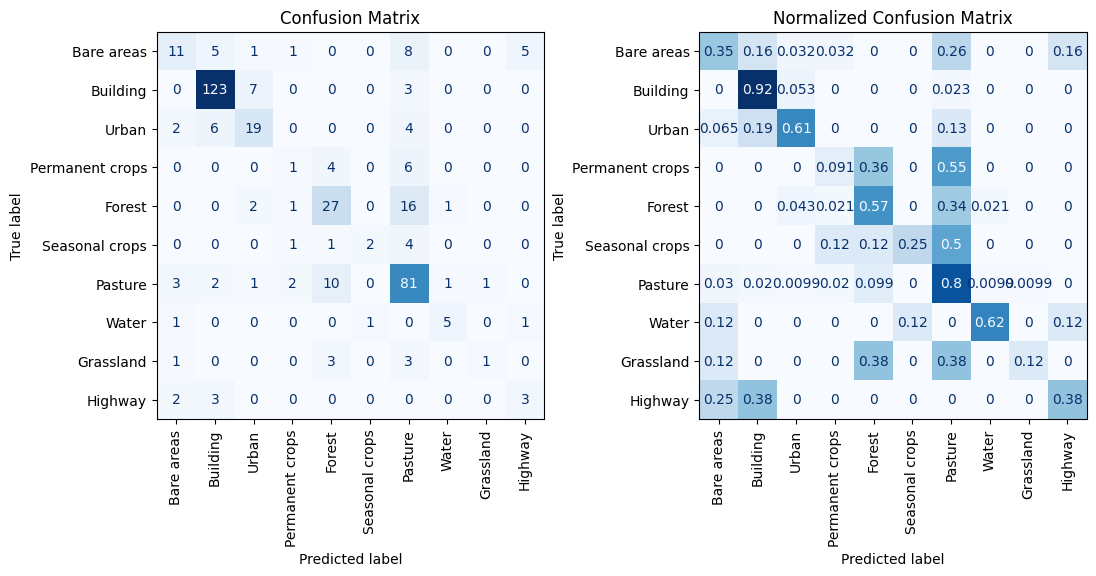


 Best Hyperparameters using cv: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 6, 'n_estimators': 100}

 Best f1 score using cv: 0.4779672868526113
Testing Overall Accuracy: 0.7072538860103627
Training Overall Accuracy: 0.9889825016202204
Testing Classification Report :
                  precision    recall  f1-score   support

     Bare areas       0.55      0.35      0.43        31
       Building       0.88      0.92      0.90       133
         Forest       0.60      0.57      0.59        47
      Grassland       0.50      0.12      0.20         8
        Highway       0.33      0.38      0.35         8
        Pasture       0.65      0.80      0.72       101
Permanent crops       0.17      0.09      0.12        11
 Seasonal crops       0.67      0.25      0.36         8
          Urban       0.63      0.61      0.62        31
          Water       0.71      0.62      0.67         8

       accuracy                           0.71       386
      macro avg      

In [50]:
grid_search_rf= rf_hyperparameter_tuning(X_train, y_train)

best_model_rf = grid_search_rf.best_estimator_

testing_overall_accuracy, training_overall_accuracy, testing_classification_accuracy = compute_accuracy(best_model_rf, X_test, y_test, X_train,y_train)
print("\n Best Hyperparameters using cv:", grid_search_rf.best_params_)
print("\n Best f1 score using cv:", grid_search_rf.best_score_)
print("Testing Overall Accuracy:", testing_overall_accuracy)
print("Training Overall Accuracy:", training_overall_accuracy)
print("Testing Classification Report :\n", testing_classification_accuracy)



 Best Hyperparameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

 Best score using cv: 0.45345453142332276


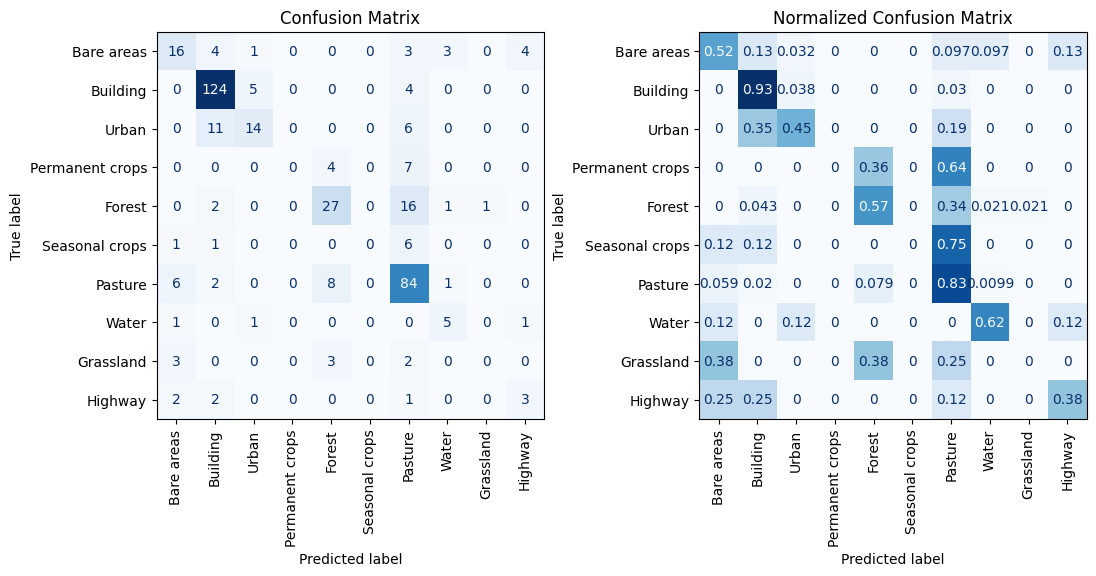


 Testing Accuracy  0.7072538860103627
Training Accuracy : 0.8379779650032404
Testing Classification:
                  precision    recall  f1-score   support

     Bare areas       0.55      0.52      0.53        31
       Building       0.85      0.93      0.89       133
         Forest       0.64      0.57      0.61        47
      Grassland       0.00      0.00      0.00         8
        Highway       0.38      0.38      0.38         8
        Pasture       0.65      0.83      0.73       101
Permanent crops       1.00      0.00      0.00        11
 Seasonal crops       1.00      0.00      0.00         8
          Urban       0.67      0.45      0.54        31
          Water       0.50      0.62      0.56         8

       accuracy                           0.71       386
      macro avg       0.62      0.43      0.42       386
   weighted avg       0.71      0.71      0.68       386



In [51]:

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'poly']
}

cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_svm = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid_svm,
    cv=cv_svm,
    n_jobs=-1,
    verbose=0,
    scoring='f1_macro'
)
grid_search_svm.fit(X_train_scaled, y_train)

best_model_svm = grid_search_svm.best_estimator_
print("\n Best Hyperparameters for SVM:", grid_search_svm.best_params_)
print("\n Best score using cv:", grid_search_svm.best_score_)

testing_overall_accuracy, training_overall_accuracy, testing_classification_accuracy = compute_accuracy(best_model_svm, X_test_scaled, y_test, X_train_scaled, y_train)
print("\n Testing Accuracy ", testing_overall_accuracy)
print("Training Accuracy :", training_overall_accuracy)
print("Testing Classification:\n", testing_classification_accuracy)


In [52]:
print("Random Forest vs Baseline:")
compare_with_baseline(best_model_rf, X_train, y_train, X_test, y_test, "Random Forest")

print("\nSVM vs Baseline:")
compare_with_baseline(best_model_svm, X_train_scaled, y_train, X_test_scaled, y_test, "SVM")

Random Forest vs Baseline:
                Model  Overall Test Accuracy
Dummy (most_frequent)               0.344560
   Dummy (stratified)               0.199482
      Dummy (uniform)               0.088083
        Random Forest               0.707254

SVM vs Baseline:
                Model  Overall Test Accuracy
Dummy (most_frequent)               0.344560
   Dummy (stratified)               0.199482
      Dummy (uniform)               0.088083
                  SVM               0.707254


,Model,Overall Test Accuracy
0,Dummy (most_frequent),0.344560
1,Dummy (stratified),0.199482
2,Dummy (uniform),0.088083
3,SVM,0.707254


#### test with random forest imbalance handling 

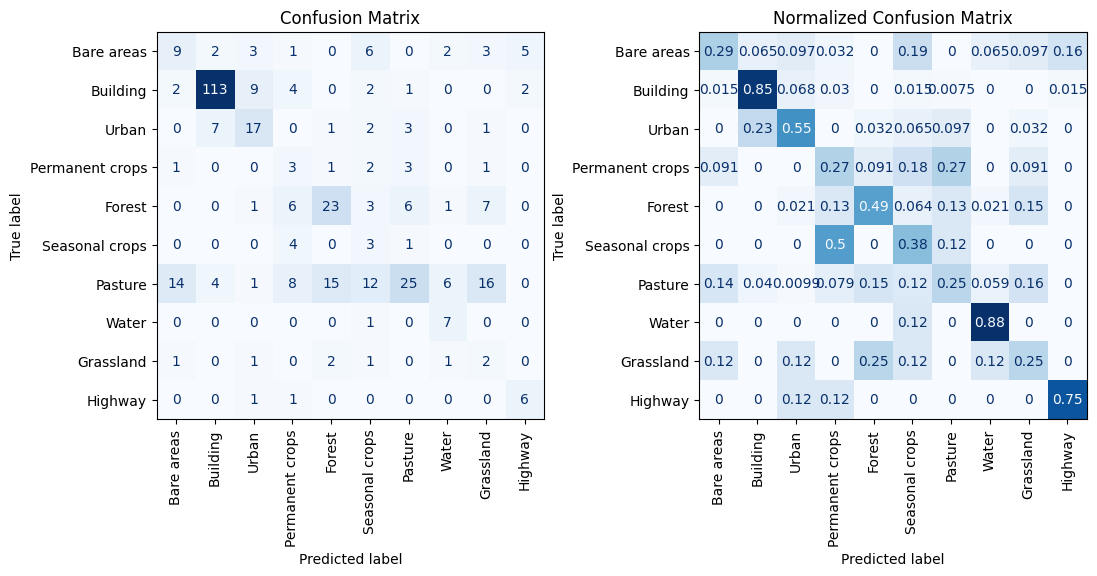


 Best Hyperparameters with Random Under Sampling: {'class_weight': 'balanced_subsample', 'max_depth': 20, 'min_samples_split': 4, 'n_estimators': 100}

 Best score using cv: 0.4533250181191358

 Testing Accuracy: 0.538860103626943
Training Accuracy: 1.0
Testing Classification Report:
                  precision    recall  f1-score   support

     Bare areas       0.33      0.29      0.31        31
       Building       0.90      0.85      0.87       133
         Forest       0.55      0.49      0.52        47
      Grassland       0.07      0.25      0.11         8
        Highway       0.46      0.75      0.57         8
        Pasture       0.64      0.25      0.36       101
Permanent crops       0.11      0.27      0.16        11
 Seasonal crops       0.09      0.38      0.15         8
          Urban       0.52      0.55      0.53        31
          Water       0.41      0.88      0.56         8

       accuracy                           0.54       386
      macro avg       0.41 

In [53]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

grid_search_rf= rf_hyperparameter_tuning(X_train_resampled, y_train_resampled)

testing_overall_accuracy, training_overall_accuracy, testing_classification_accuracy = compute_accuracy(grid_search_rf.best_estimator_, X_test, y_test, X_train_resampled, y_train_resampled)

print("\n Best Hyperparameters with Random Under Sampling:", grid_search_rf.best_params_)
print("\n Best score using cv:", grid_search_rf.best_score_)

print("\n Testing Accuracy:", testing_overall_accuracy)
print("Training Accuracy:", training_overall_accuracy)
print("Testing Classification Report:\n", testing_classification_accuracy)


### SMOTE

https://medium.com/sfu-cspmp/surviving-in-a-random-forest-with-imbalanced-datasets-b98b963d52eb 

SMOTE (Synthetic Minority Oversampling Technique) is one of the oversampling techniques that use a minority class to generate synthetic samples. In consequence, it overcomes the overfitting problem raised by random oversampling. SMOTE works by generating instances that are close in feature space, using interpolation between positive cases that are close to each other. It randomly selects a minority class instance and finds its nearest neighbour. Then it creates synthetic models by randomly choosing one of the neighbours and forms a line segment in the feature space. 

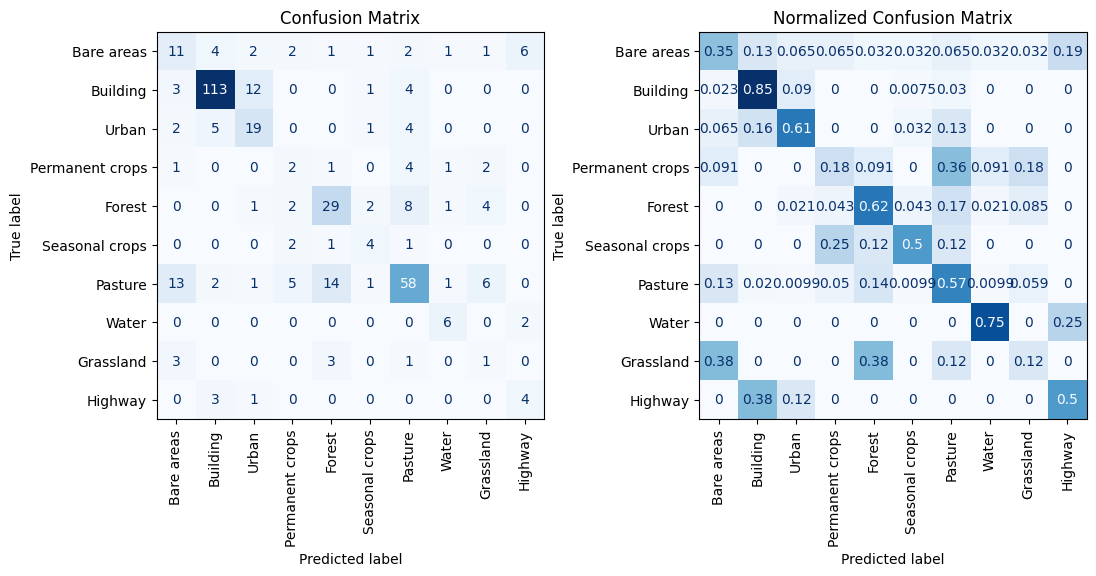


 Best Hyperparameters with SMOTE: {'class_weight': 'balanced_subsample', 'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}

 Best score using cv: 0.9110816902845565
Testing Accuracy: 0.6398963730569949
Training Accuracy: 1.0
Testing Classification Report:
                  precision    recall  f1-score   support

     Bare areas       0.33      0.35      0.34        31
       Building       0.89      0.85      0.87       133
         Forest       0.59      0.62      0.60        47
      Grassland       0.07      0.12      0.09         8
        Highway       0.33      0.50      0.40         8
        Pasture       0.71      0.57      0.63       101
Permanent crops       0.15      0.18      0.17        11
 Seasonal crops       0.40      0.50      0.44         8
          Urban       0.53      0.61      0.57        31
          Water       0.60      0.75      0.67         8

       accuracy                           0.64       386
      macro avg       0.46      0.51      0.

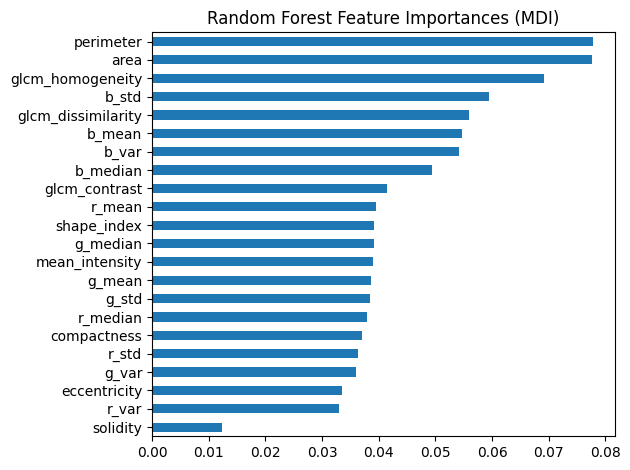

In [34]:
from imblearn.over_sampling import SMOTE # source : https://medium.com/sfu-cspmp/surviving-in-a-random-forest-with-imbalanced-datasets-b98b963d52eb

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

grid_search_rf= rf_hyperparameter_tuning(X_train_resampled, y_train_resampled)

testing_overall_accuracy, training_overall_accuracy, testing_classification_accuracy = compute_accuracy(grid_search_rf.best_estimator_, X_test, y_test, X_train_resampled, y_train_resampled)

print("\n Best Hyperparameters with SMOTE:", grid_search_rf.best_params_)
print("\n Best score using cv:", grid_search_rf.best_score_)

print("Testing Accuracy:", testing_overall_accuracy)
print("Training Accuracy:", training_overall_accuracy)
print("Testing Classification Report:\n", testing_classification_accuracy)

_ = plot_rf_feature_importances(grid_search_rf.best_estimator_)